In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [2]:
# 1. Cargar el conjunto de datos Wine
wine_raw = load_wine()
df_wine = pd.DataFrame(wine_raw.data, columns=wine_raw.feature_names)
df_wine['class'] = pd.Categorical.from_codes(wine_raw.target, wine_raw.target_names)

In [3]:
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [4]:
df_wine.shape, df_wine.columns, df_wine.dtypes

((178, 14),
 Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
        'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
        'proanthocyanins', 'color_intensity', 'hue',
        'od280/od315_of_diluted_wines', 'proline', 'class'],
       dtype='str'),
 alcohol                          float64
 malic_acid                       float64
 ash                              float64
 alcalinity_of_ash                float64
 magnesium                        float64
 total_phenols                    float64
 flavanoids                       float64
 nonflavanoid_phenols             float64
 proanthocyanins                  float64
 color_intensity                  float64
 hue                              float64
 od280/od315_of_diluted_wines     float64
 proline                          float64
 class                           category
 dtype: object)

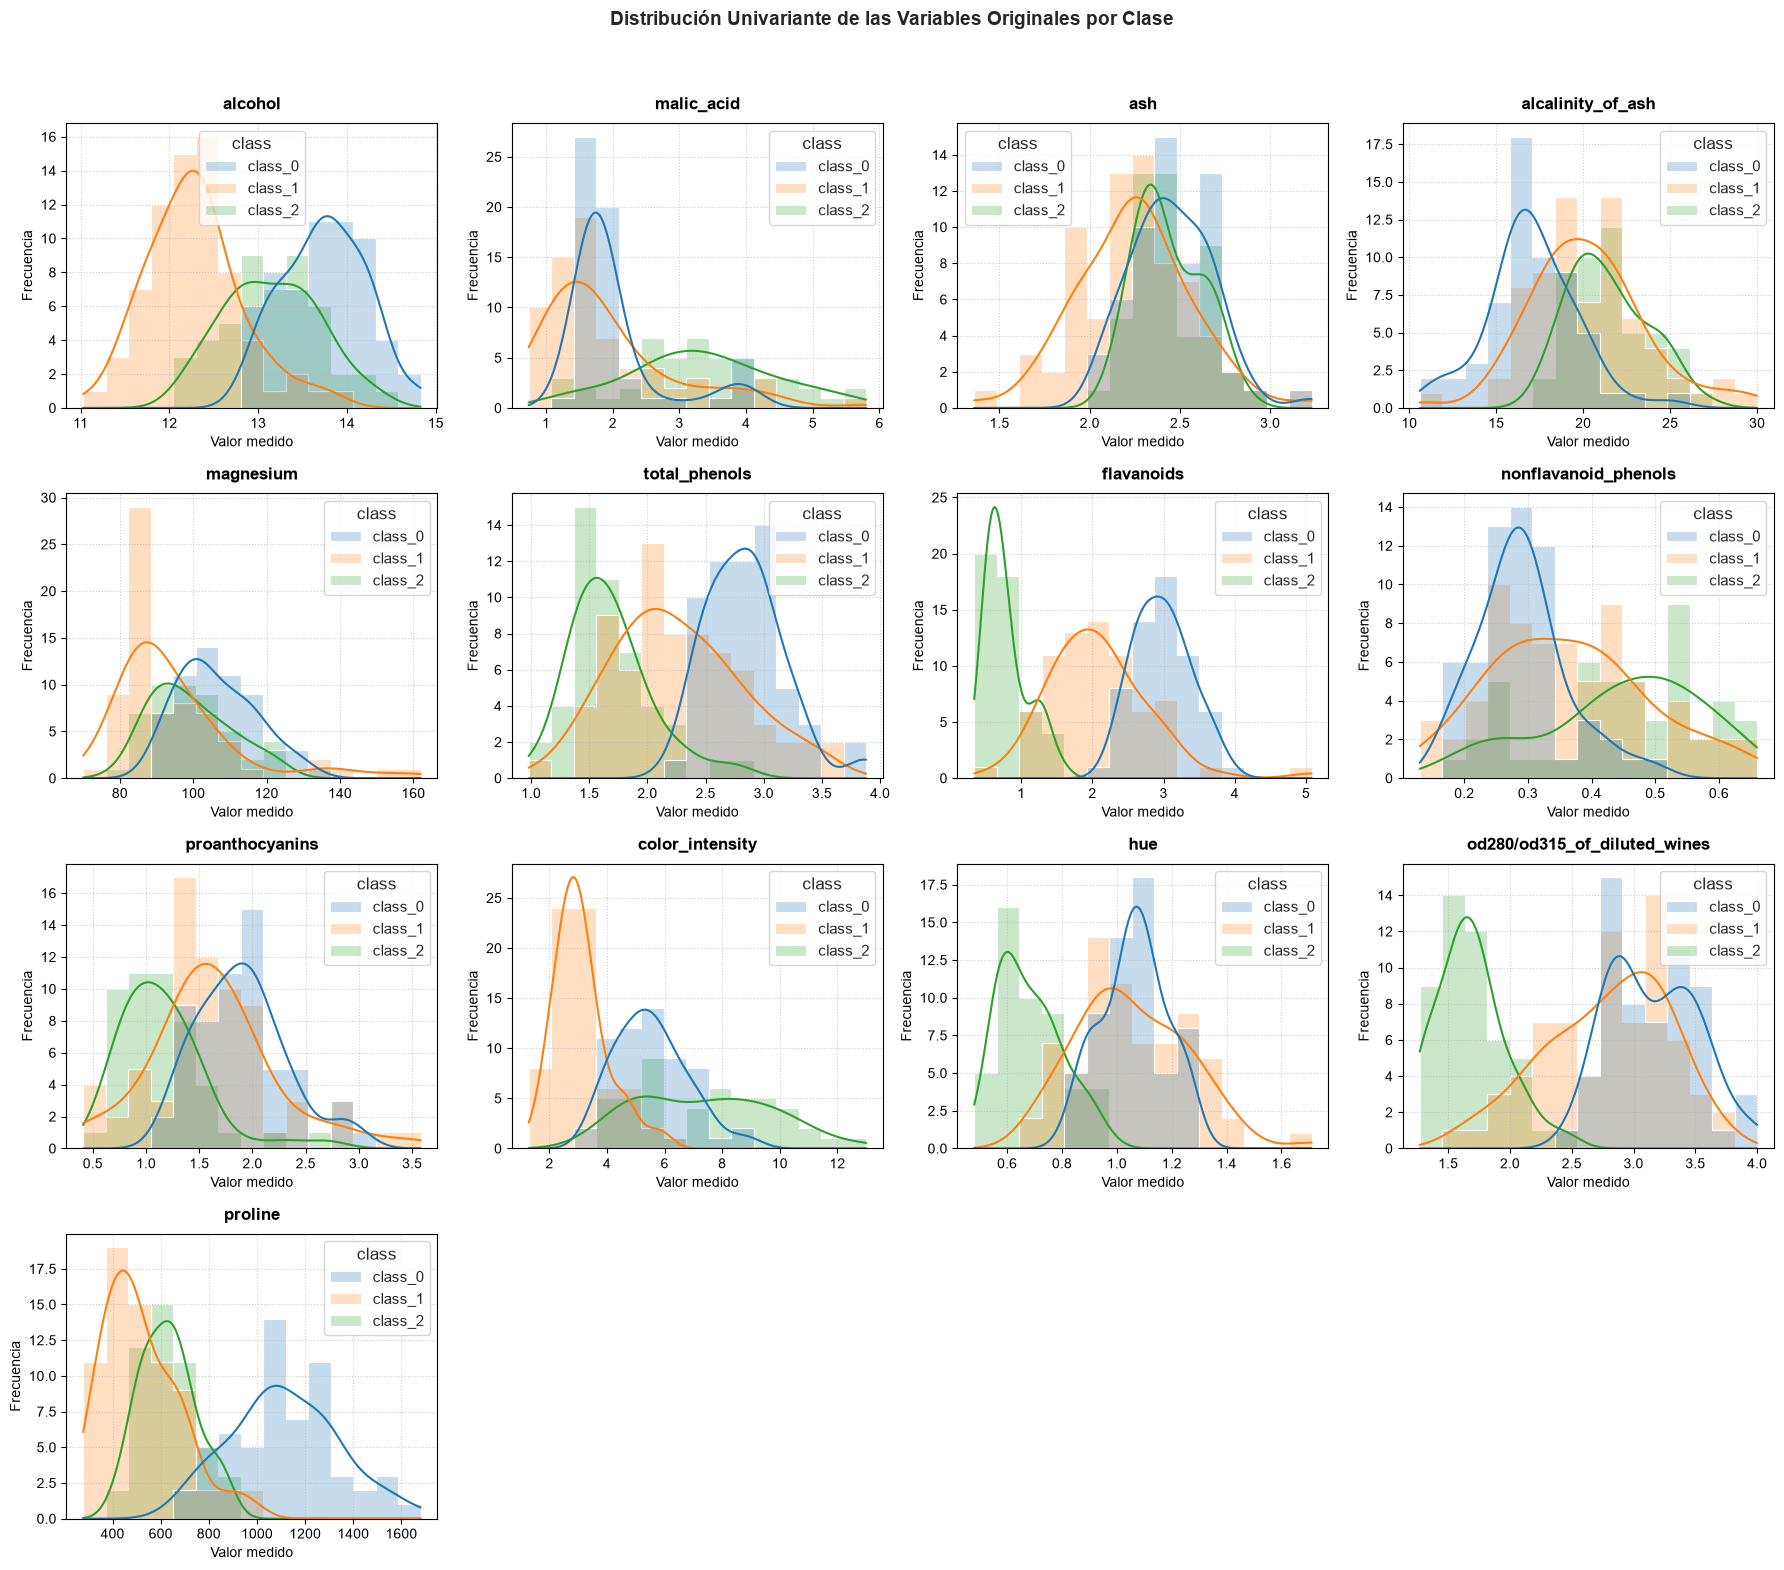

In [5]:
# Configuración de la figura en disposición 4x4 (13 variables)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# Mantenimiento de la paleta de colores para coherencia gráfica
palette = {'class_0': '#1f77b4', 'class_1': '#ff7f0e', 'class_2': '#2ca02c'}

sns.set_theme(style="ticks")

# Variables continuas originales
variables_originales = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
        'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
        'proanthocyanins', 'color_intensity', 'hue',
        'od280/od315_of_diluted_wines', 'proline']

# 2. Iteración para generación de histogramas con KDE
for i, var in enumerate(variables_originales):
    sns.histplot(
        data=df_wine,
        x=var,
        hue='class',
        kde=True,
        element='step',
        palette=palette,
        ax=axes[i],
        edgecolor='white',
        linewidth=0.8,
        bins=15
    )
    axes[i].set_title(variables_originales[i], fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Valor medido', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Ocultar los ejes sobrantes (16 slots para 13 variables)
for j in range(len(variables_originales), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución Univariante de las Variables Originales por Clase', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:
# 2. Ingenieria de características: Codificación indicador (dummy/one-hot manual)
# Equivale al mutate() + ifelse() de dplyr mediante evaluación vectorial
wine_codificado = df_wine.copy()
wine_codificado['x_class_0'] = (wine_codificado['class'] == 'class_0').astype(int)
wine_codificado['x_class_1'] = (wine_codificado['class'] == 'class_1').astype(int)

# 3. Selección del subconjunto de variables
# Equivale a select() de dplyr
columnas_analisis = list(wine_raw.feature_names) + ['x_class_0', 'x_class_1']
datos_analisis = wine_codificado[columnas_analisis]

In [7]:
# 4. Vector de medias vectoriales
vector_medias = datos_analisis.mean()
print("--- Vector de Medias ---")
print(vector_medias)
print("\n")

# 4. Vector de desvios
vector_desvios = datos_analisis-vector_medias
print("--- Vector de Desvios ---")
print(vector_desvios)
print("\n")

# 5. Matriz de Covarianza (muestra)
matriz_cov = datos_analisis.cov()
print("--- Matriz de Covarianza (Redondeada a 3 decimales) ---")
print(matriz_cov.round(3))
print("\n")

# 6. Matriz de Correlación (Pearson)
matriz_cor = datos_analisis.corr()
print("--- Matriz de Correlación (Redondeada a 3 decimales) ---")
print(matriz_cor.round(3))

--- Vector de Medias ---
alcohol                          13.000618
malic_acid                        2.336348
ash                               2.366517
alcalinity_of_ash                19.494944
magnesium                        99.741573
total_phenols                     2.295112
flavanoids                        2.029270
nonflavanoid_phenols              0.361854
proanthocyanins                   1.590899
color_intensity                   5.058090
hue                               0.957449
od280/od315_of_diluted_wines      2.611685
proline                         746.893258
x_class_0                         0.331461
x_class_1                         0.398876
dtype: float64


--- Vector de Desvios ---
      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0    1.229382   -0.626348  0.063483          -3.894944  27.258427   
1    0.199382   -0.556348 -0.226517          -8.294944   0.258427   
2    0.159382    0.023652  0.303483          -0.894944   1.258427   
3    1.3693

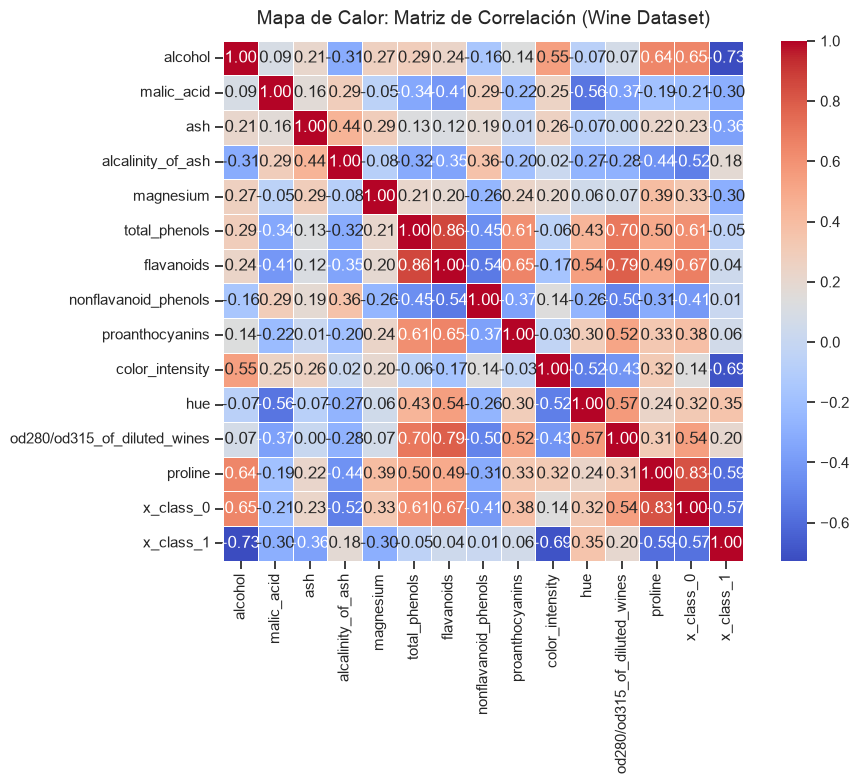

In [8]:
# Configuración del gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_cor, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=True,
    linewidths=0.5,
    square=True
)

plt.title("Mapa de Calor: Matriz de Correlación (Wine Dataset)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("heatmap_correl.png", dpi=300)
plt.show()

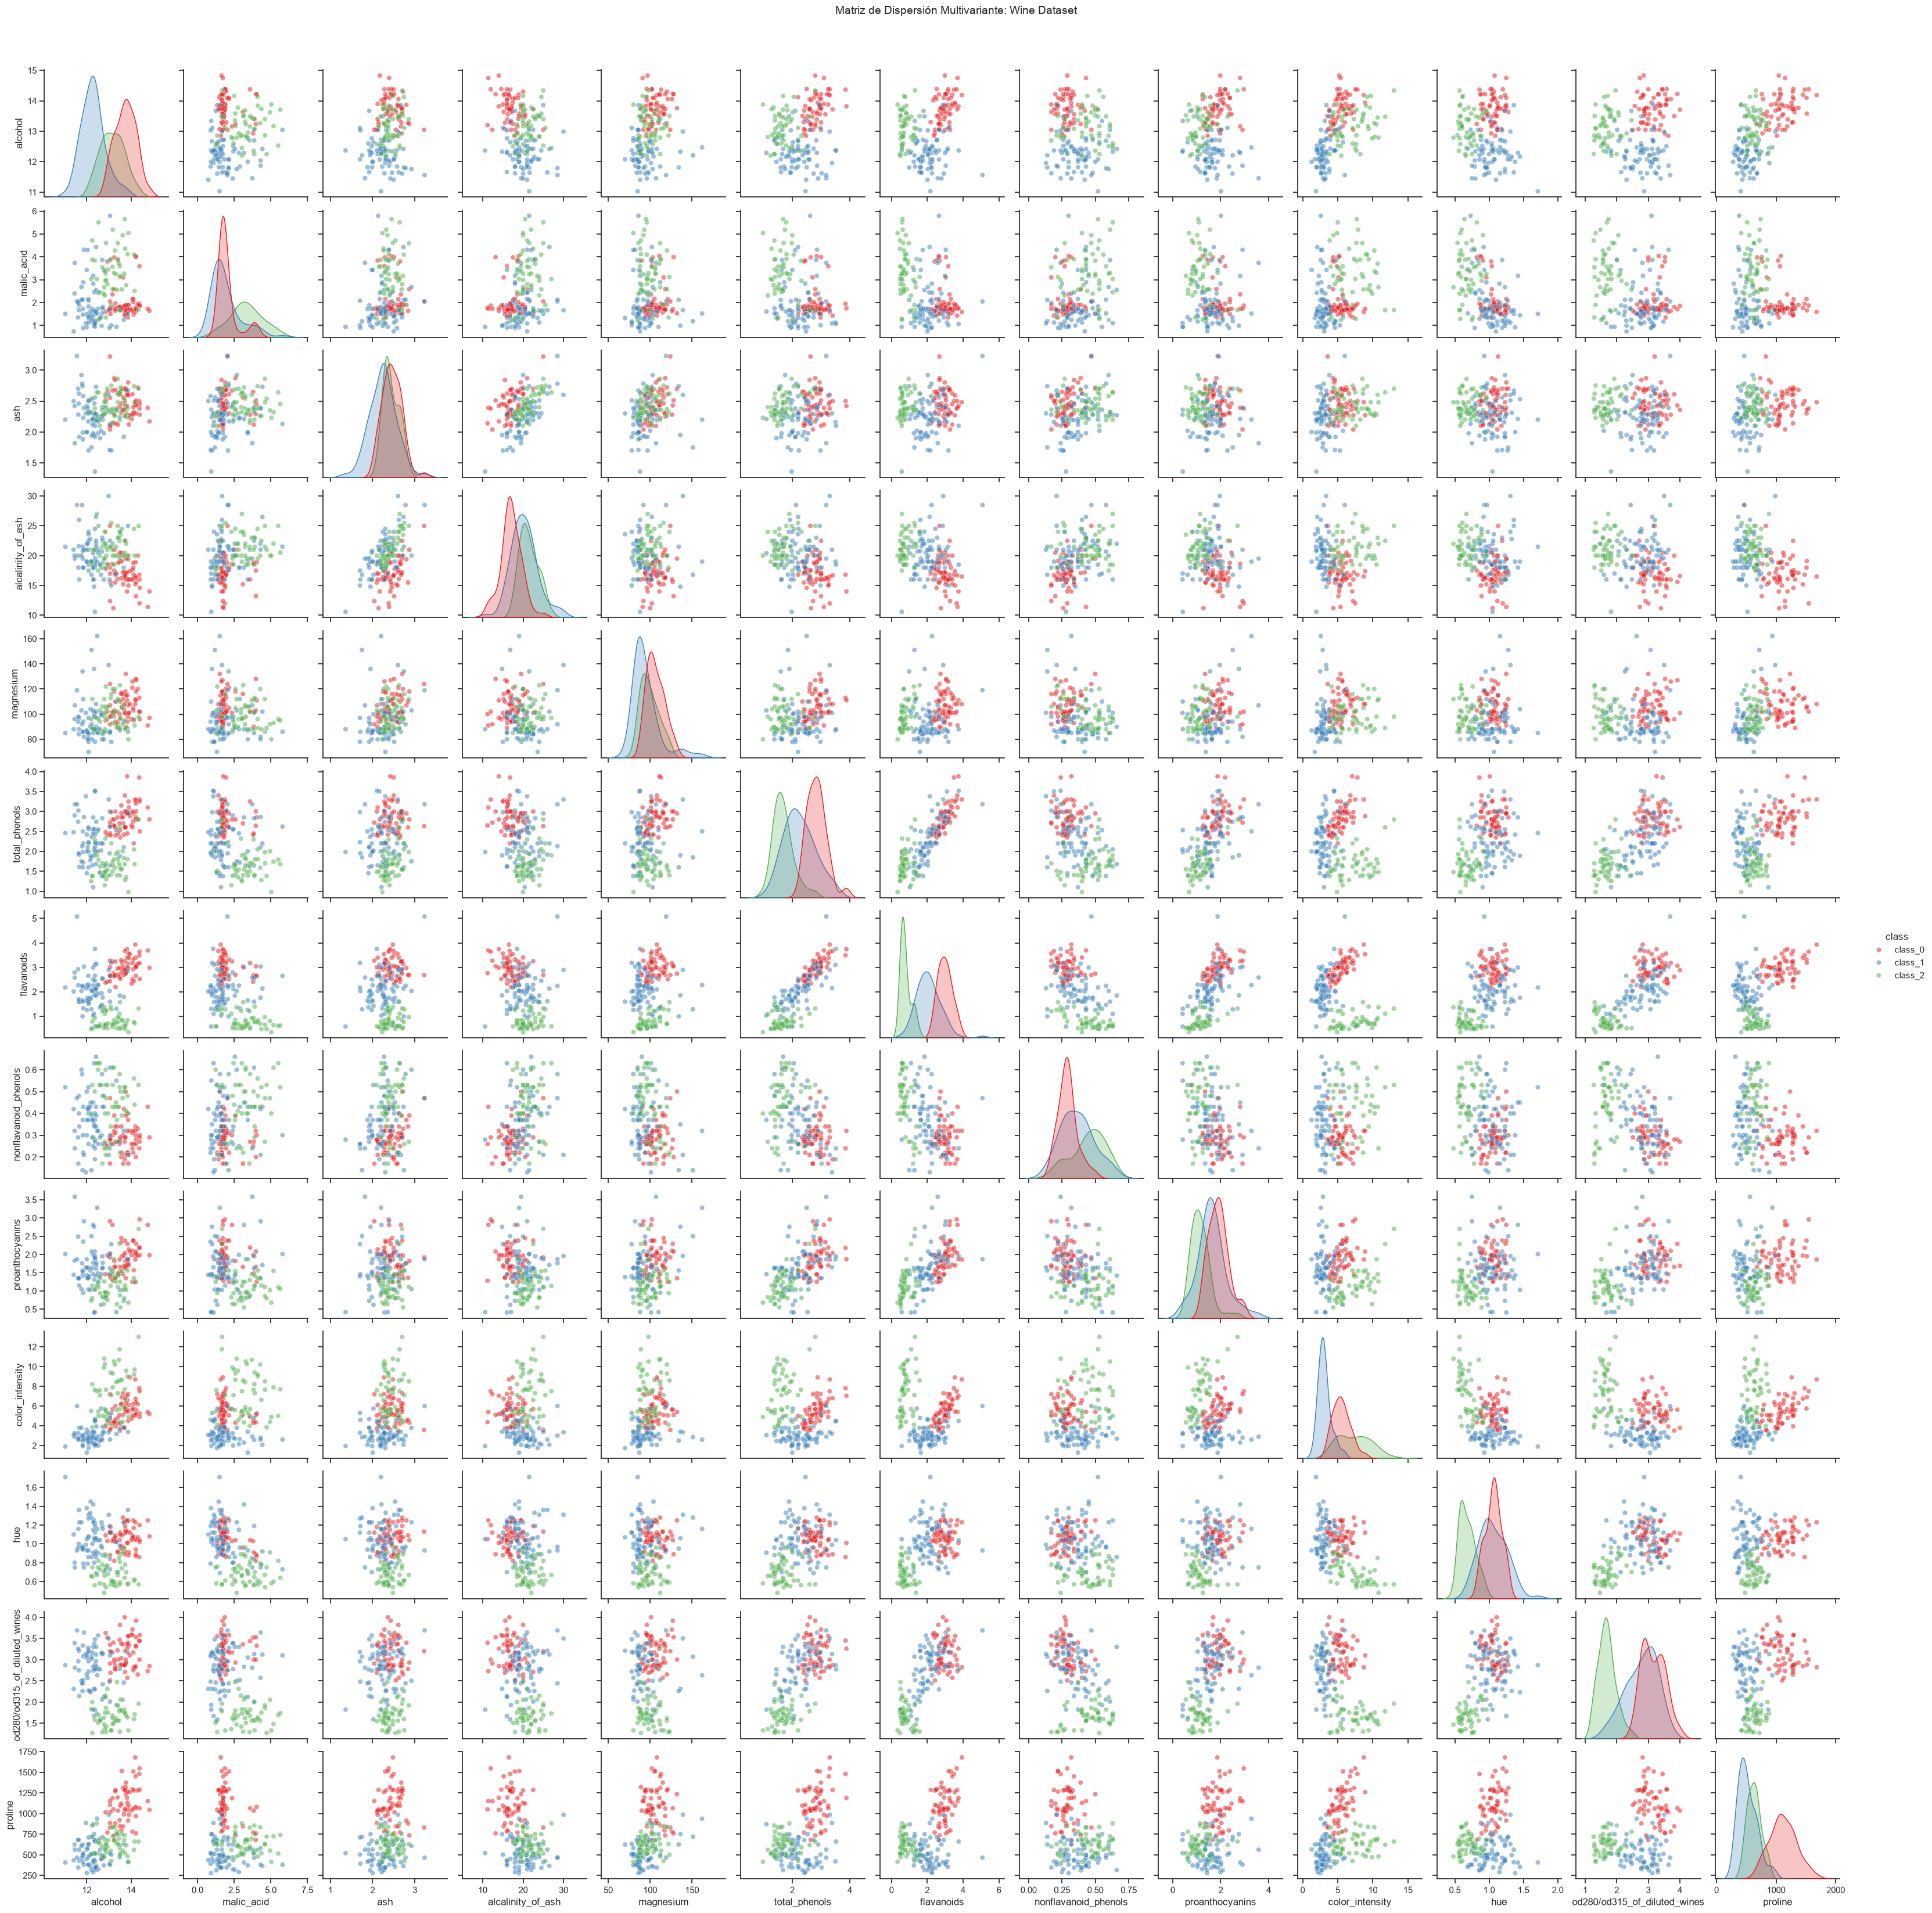

In [9]:
# 7. Matriz de dispersión multivariante (Equivalente a GGally::ggpairs)
sns.set_theme(style="ticks")
grafico_multivariante = sns.pairplot(
    wine_codificado,
    vars=list(wine_raw.feature_names),
    hue='class',
    palette='Set1',
    plot_kws={'alpha': 0.5},
    diag_kind='kde'  # Estimación de densidad kernel en la diagonal
)

grafico_multivariante.fig.suptitle(
    "Matriz de Dispersión Multivariante: Wine Dataset", 
    y=1.02, 
    fontsize=14
)

plt.show()

# Análisis de componentes principales

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
# Standardize variables (z-score normalization for PCA based on correlation structure)
scaler = StandardScaler()
datos_analisis_scaled = scaler.fit_transform(datos_analisis)

# PCA
pca = PCA()
datos_analisis_pca = pca.fit_transform(datos_analisis_scaled)

# 2. Scree Plot
eigenvalues = pca.explained_variance_  # Autovalores (\lambda_i)
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

# Loadings (eigenvectors * sqrt(eigenvalues))
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

print("Autovalor:", eigenvalues.round(4))
print("Var exp:", var_exp.round(4))
print("Cum var:", cum_var_exp.round(4))
print("Loadings PC1:", loadings[:, 0].round(3))
print("Loadings PC2:", loadings[:, 1].round(3))

Autovalor: [5.3949 3.4797 1.4799 0.9435 0.8957 0.6991 0.5571 0.3516 0.3206 0.2616
 0.2282 0.1708 0.1499 0.1158 0.0363]
Var exp: [0.3576 0.2307 0.0981 0.0625 0.0594 0.0463 0.0369 0.0233 0.0213 0.0173
 0.0151 0.0113 0.0099 0.0077 0.0024]
Cum var: [0.3576 0.5883 0.6864 0.749  0.8083 0.8547 0.8916 0.9149 0.9362 0.9535
 0.9687 0.98   0.9899 0.9976 1.    ]
Loadings PC1: [ 0.478 -0.444  0.091 -0.545  0.368  0.842  0.891 -0.616  0.642 -0.036
  0.55   0.754  0.748  0.864 -0.229]
Loadings PC2: [-0.708 -0.455 -0.441 -0.008 -0.333  0.114  0.223 -0.173  0.151 -0.835
  0.553  0.421 -0.467 -0.343  0.914]


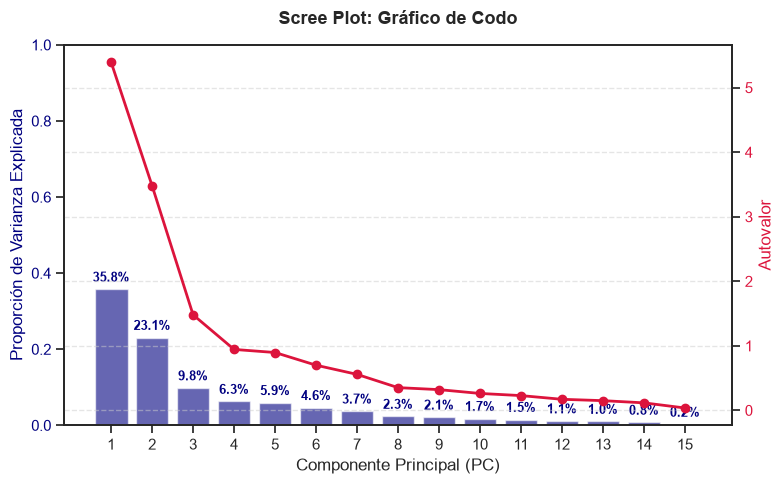

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart for individual variance
bars = ax1.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, color='navy', label='Varianza Individual')
ax1.set_xlabel('Componente Principal (PC)', fontsize=12)
ax1.set_ylabel('Proporción de Varianza Explicada', fontsize=12, color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticks(range(1, len(var_exp) + 1))
ax1.set_ylim(0, 1)

# Line chart for cumulative variance
ax2 = ax1.twinx()
line = ax2.plot(range(1, len(var_exp) + 1), eigenvalues, color='crimson', marker='o', linewidth=2, label='Autovalor')
ax2.set_ylabel('Autovalor', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
#ax2.set_ylim(0, 1.05)

# Annotate percentages
for i, (v, c) in enumerate(zip(var_exp, cum_var_exp)):
    ax1.text(i+1, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=9, color='navy', fontweight='bold')

plt.title('Scree Plot: Gráfico de Codo', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=300)
#plt.close()


Por criterio de Kaiser las componentes 1 y 2 tienen autovalores mayores a 1.


# Analizamos datos en espacio reducido R2

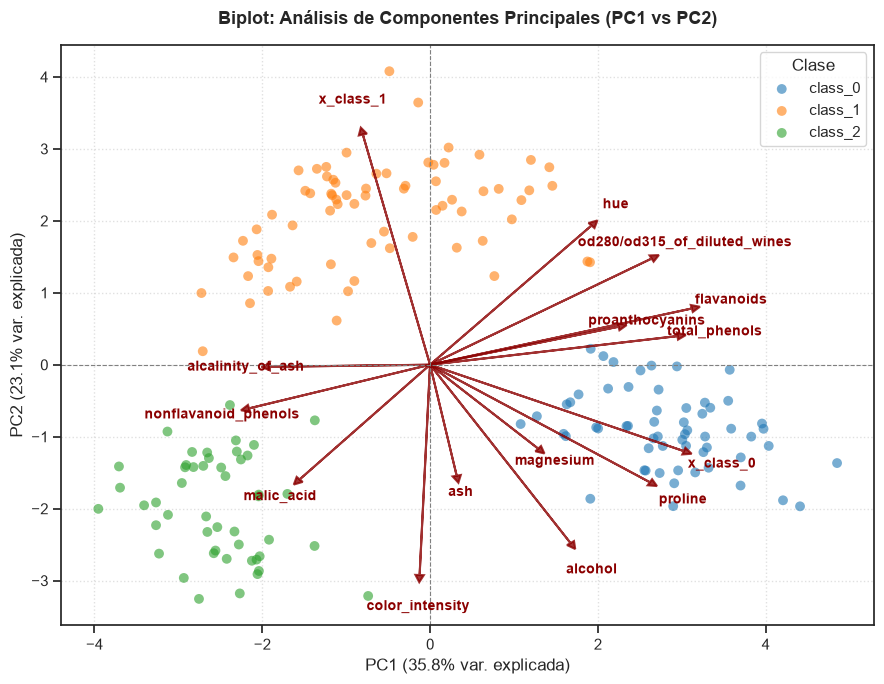

In [13]:
# 3. Biplot (PC1 vs PC2)
plt.figure(figsize=(9, 7))
# Scatter plot of scores
class_colors = {'class_0': '#1f77b4', 'class_1': '#ff7f0e', 'class_2': '#2ca02c'}
for cl in df_wine['class'].unique():
    mask = (df_wine['class'] == cl).to_numpy()
    plt.scatter(datos_analisis_pca[mask, 0], datos_analisis_pca[mask, 1], label=cl, alpha=0.6, c=class_colors[cl], edgecolors='none', s=50)

# Loadings (eigenvectors * sqrt(eigenvalues)) or raw loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Scale factor for display
scale = 3.5

for i, feature in enumerate(columnas_analisis):
    plt.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale, 
              color='darkred', alpha=0.8, head_width=0.1, head_length=0.1, linewidth=1.5)
    # Adjust annotation text positioning slightly
    plt.text(loadings[i, 0]*scale * 1.15, loadings[i, 1]*scale * 1.15, feature, 
             color='darkred', ha='center', va='center', fontweight='bold', fontsize=10)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% var. explicada)', fontsize=12)
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% var. explicada)', fontsize=12)
plt.title('Biplot: Análisis de Componentes Principales (PC1 vs PC2)', fontsize=13, fontweight='bold', pad=15)
plt.legend(title='Clase', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('biplot.png', dpi=300)
#plt.close()

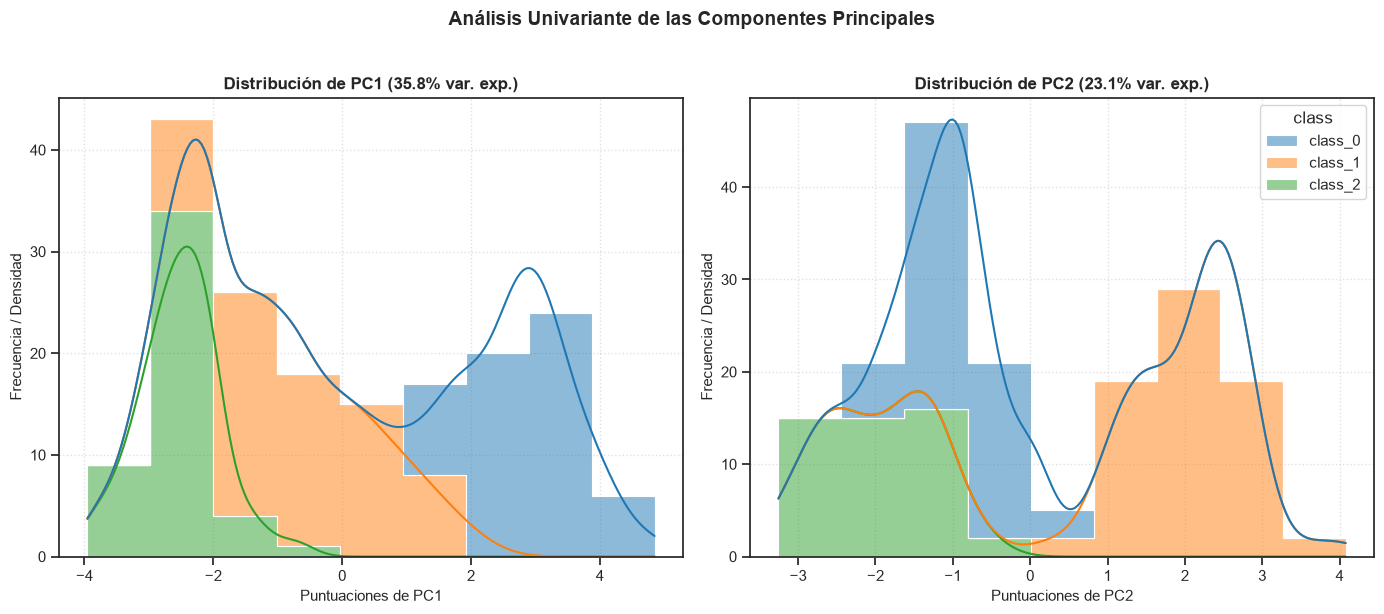

In [14]:
df_pca_scores = pd.DataFrame(datos_analisis_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_scores['class'] = df_wine['class'].values

# 2. Creación de histogramas (en una figura con subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="ticks")

# Colores consistentes para clases (como en el biplot)
palette = {'class_0': '#1f77b4', 'class_1': '#ff7f0e', 'class_2': '#2ca02c'}

# Histograma PC1
sns.histplot(
    data=df_pca_scores,
    x='PC1',
    hue='class',
    kde=True,
    multiple='stack', # Apilar para mostrar totales y desglose
    element='step',
    palette=palette,
    ax=axes[0],
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title(f'Distribución de PC1 ({var_exp[0]*100:.1f}% var. exp.)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntuaciones de PC1', fontsize=11)
axes[0].set_ylabel('Frecuencia / Densidad', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Histograma PC2
sns.histplot(
    data=df_pca_scores,
    x='PC2',
    hue='class',
    kde=True,
    multiple='stack', # Apilar para mostrar totales y desglose
    element='step',
    palette=palette,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title(f'Distribución de PC2 ({var_exp[1]*100:.1f}% var. exp.)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Puntuaciones de PC2', fontsize=11)
axes[1].set_ylabel('Frecuencia / Densidad', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove() # Remover la leyenda interna
# axes[1].get_legend().remove() # seaborn_histplot ya las quita si hue está activo y hay subplots, a veces.

fig.suptitle('Análisis Univariante de las Componentes Principales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogramas_pc1_pc2.png', dpi=300)
plt.show()